In [1]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('IMDB.csv')

In [3]:
df.shape

(50000, 2)

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df['review'].iloc[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


### Preprocessing

In [7]:
def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text) # replace <br(zero or more spaces)/> tags with one space.
    text = re.sub(r"\s+", " ", text) # replace one or more spaces with one space.
    return text.strip()

In [8]:
clean_text(df['review'].iloc[0])[:500]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word. It is called OZ as that is the nickna"

In [9]:
df['sentiment'] = df['sentiment'].map({'negative':0, 'positive':1})

In [10]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [11]:
df['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

In [12]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['sentiment'])

In [13]:
train_df.shape

(40000, 2)

In [14]:
temp_df.shape

(10000, 2)

In [15]:
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['sentiment'])

In [16]:
val_df.shape

(5000, 2)

In [17]:
test_df.shape

(5000, 2)

In [18]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

In [19]:
text = train_df['review'].iloc[0]

In [20]:
text

'I caught this little gem totally by accident back in 1980 or \'81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile and nods. That made it even funnier! You gotta see "Chewabacca" played by what looks like a Muppet! It was extremely silly and stupid...but I couldn\'t stop laughing. Most of the dialogue was drowned out because of all the laughter. Also if you know "Star Wars" pretty well it\'s even funnier--they deliberately poke fun at some of the dialogue. This REALLY works with an audience! A definite 10!'

In [21]:
encoded = tokenizer(text, max_length=128, padding='max_length', truncation=True)

In [22]:
encoded

{'input_ids': [101, 1045, 3236, 2023, 2210, 17070, 6135, 2011, 4926, 2067, 1999, 3150, 2030, 1005, 6282, 1012, 1045, 2001, 2012, 1037, 6308, 3004, 2000, 2156, 2048, 2214, 10021, 16596, 1011, 10882, 5691, 1012, 1996, 3004, 2001, 8966, 2440, 1998, 1006, 2007, 2053, 5432, 1007, 2027, 3662, 1037, 9129, 1997, 16596, 1011, 10882, 2460, 11867, 21511, 2015, 1006, 2000, 2131, 2149, 1999, 1996, 6888, 1007, 1012, 2087, 2020, 5399, 19142, 2021, 2023, 2234, 2006, 1998, 1010, 2306, 3823, 1010, 1996, 4378, 2001, 1999, 1044, 27268, 22420, 2015, 999, 1996, 5221, 4756, 2234, 2043, 2027, 3662, 1000, 4615, 21110, 2050, 1000, 2383, 4121, 21229, 21122, 2015, 2612, 1997, 2606, 2006, 2014, 2132, 1012, 2016, 3504, 2012, 1996, 4950, 1010, 3957, 1037, 11844, 2868, 1998, 11232, 1012, 2008, 2081, 2009, 2130, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [23]:
print(encoded['input_ids'])

[101, 1045, 3236, 2023, 2210, 17070, 6135, 2011, 4926, 2067, 1999, 3150, 2030, 1005, 6282, 1012, 1045, 2001, 2012, 1037, 6308, 3004, 2000, 2156, 2048, 2214, 10021, 16596, 1011, 10882, 5691, 1012, 1996, 3004, 2001, 8966, 2440, 1998, 1006, 2007, 2053, 5432, 1007, 2027, 3662, 1037, 9129, 1997, 16596, 1011, 10882, 2460, 11867, 21511, 2015, 1006, 2000, 2131, 2149, 1999, 1996, 6888, 1007, 1012, 2087, 2020, 5399, 19142, 2021, 2023, 2234, 2006, 1998, 1010, 2306, 3823, 1010, 1996, 4378, 2001, 1999, 1044, 27268, 22420, 2015, 999, 1996, 5221, 4756, 2234, 2043, 2027, 3662, 1000, 4615, 21110, 2050, 1000, 2383, 4121, 21229, 21122, 2015, 2612, 1997, 2606, 2006, 2014, 2132, 1012, 2016, 3504, 2012, 1996, 4950, 1010, 3957, 1037, 11844, 2868, 1998, 11232, 1012, 2008, 2081, 2009, 2130, 102]


In [24]:
print(encoded['attention_mask'])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [25]:
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'])

In [26]:
print(tokens)

['[CLS]', 'i', 'caught', 'this', 'little', 'gem', 'totally', 'by', 'accident', 'back', 'in', '1980', 'or', "'", '81', '.', 'i', 'was', 'at', 'a', 'revival', 'theatre', 'to', 'see', 'two', 'old', 'silly', 'sci', '-', 'fi', 'movies', '.', 'the', 'theatre', 'was', 'packed', 'full', 'and', '(', 'with', 'no', 'warning', ')', 'they', 'showed', 'a', 'bunch', 'of', 'sci', '-', 'fi', 'short', 'sp', '##oof', '##s', '(', 'to', 'get', 'us', 'in', 'the', 'mood', ')', '.', 'most', 'were', 'somewhat', 'amusing', 'but', 'this', 'came', 'on', 'and', ',', 'within', 'seconds', ',', 'the', 'audience', 'was', 'in', 'h', '##yst', '##eric', '##s', '!', 'the', 'biggest', 'laugh', 'came', 'when', 'they', 'showed', '"', 'princess', 'lai', '##a', '"', 'having', 'huge', 'cinnamon', 'bun', '##s', 'instead', 'of', 'hair', 'on', 'her', 'head', '.', 'she', 'looks', 'at', 'the', 'camera', ',', 'gives', 'a', 'grim', 'smile', 'and', 'nods', '.', 'that', 'made', 'it', 'even', '[SEP]']


In [27]:
text

'I caught this little gem totally by accident back in 1980 or \'81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile and nods. That made it even funnier! You gotta see "Chewabacca" played by what looks like a Muppet! It was extremely silly and stupid...but I couldn\'t stop laughing. Most of the dialogue was drowned out because of all the laughter. Also if you know "Star Wars" pretty well it\'s even funnier--they deliberately poke fun at some of the dialogue. This REALLY works with an audience! A definite 10!'

### Loading data for the Transformer Input

In [28]:
class Dataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe["review"].tolist()
        self.labels = dataframe["sentiment"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoded = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [29]:
train_dataset = Dataset(train_df, tokenizer)
val_dataset = Dataset(val_df, tokenizer)
test_dataset = Dataset(test_df, tokenizer)

In [30]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [31]:
print(train_dataset[0])

{'input_ids': tensor([  101,  1045,  3236,  2023,  2210, 17070,  6135,  2011,  4926,  2067,
         1999,  3150,  2030,  1005,  6282,  1012,  1045,  2001,  2012,  1037,
         6308,  3004,  2000,  2156,  2048,  2214, 10021, 16596,  1011, 10882,
         5691,  1012,  1996,  3004,  2001,  8966,  2440,  1998,  1006,  2007,
         2053,  5432,  1007,  2027,  3662,  1037,  9129,  1997, 16596,  1011,
        10882,  2460, 11867, 21511,  2015,  1006,  2000,  2131,  2149,  1999,
         1996,  6888,  1007,  1012,  2087,  2020,  5399, 19142,  2021,  2023,
         2234,  2006,  1998,  1010,  2306,  3823,  1010,  1996,  4378,  2001,
         1999,  1044, 27268, 22420,  2015,   999,  1996,  5221,  4756,  2234,
         2043,  2027,  3662,  1000,  4615, 21110,  2050,  1000,  2383,  4121,
        21229, 21122,  2015,  2612,  1997,  2606,  2006,  2014,  2132,  1012,
         2016,  3504,  2012,  1996,  4950,  1010,  3957,  1037, 11844,  2868,
         1998, 11232,  1012,  2008,  2081,  2009, 

In [32]:
batch = next(iter(train_loader))

In [33]:
batch

{'input_ids': tensor([[  101,  1045,  3236,  ...,  1996,  1047,   102],
         [  101, 14439,  4632,  ...,  2129,  1996,   102],
         [  101,  2027,  2106,  ...,  2013,  2023,   102],
         ...,
         [  101,  2023,  2003,  ...,  1012,  5791,   102],
         [  101,  2023,  2143,  ...,  1012,  1998,   102],
         [  101,  2035,  6077,  ...,  2000,  2079,   102]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]),
 'label': tensor([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 1, 1, 1, 0, 1])}

In [34]:
batch['input_ids'].shape

torch.Size([32, 128])

In [35]:
# token IDs of first item in the batch
batch['input_ids'][0]

tensor([  101,  1045,  3236,  2023,  1037,  2261,  2706,  3283,  2006,  2155,
         3149,  1010,  1998,  2383,  2070,  5758,  1997,  1996,  2694,  2265,
         2013,  2026,  3360,  1010,  2787,  2000,  3422,  2009,  2247,  2007,
         2026,  1018,  2095,  2214,  2684,  1012,  1045,  2323,  2031,  2288,
         2070, 18147, 23827,  2000,  2175,  2247,  2007,  2009,  1010,  1005,
         3426,  2023,  2003,  2074, 13576,   999,  2025,  2069,  2003,  2009,
         1037,  3315,  2007, 15703,  2135,  5293, 10880, 13281,  1010,  1996,
         2128, 24871, 18178,  2229,  2100,  3896,  1998, 12081,  2015,  2011,
         3340,  2146,  2627,  2037,  7268,  3539,  2015,  1010,  2009,  3849,
         2000,  2031,  2042,  2550,  2004,  8307,  1005,  1055,  2204,  5648,
         4440,  1012,  3331, 28453,  1010,  2329,  2336,  2521,  2205,  2214,
         2005,  2023,  2785,  1997, 10231,  1012,  1012,  1012,  1999,  1996,
         2616,  1997,  1047,  7946,  3723,  1996,  1047,   102])

In [36]:
id_tkn = tokenizer.convert_ids_to_tokens(batch['input_ids'][0])

In [37]:
print(id_tkn)

['[CLS]', 'i', 'caught', 'this', 'a', 'few', 'months', 'ago', 'on', 'family', 'channel', ',', 'and', 'having', 'some', 'memories', 'of', 'the', 'tv', 'show', 'from', 'my', 'youth', ',', 'decided', 'to', 'watch', 'it', 'along', 'with', 'my', '4', 'year', 'old', 'daughter', '.', 'i', 'should', 'have', 'got', 'some', 'psychedelic', 'mushrooms', 'to', 'go', 'along', 'with', 'it', ',', "'", 'cause', 'this', 'is', 'just', 'bizarre', '!', 'not', 'only', 'is', 'it', 'a', 'musical', 'with', 'annoying', '##ly', 'forget', '##table', 'tunes', ',', 'the', 're', '##quisite', 'che', '##es', '##y', 'effects', 'and', 'cameo', '##s', 'by', 'stars', 'long', 'past', 'their', 'collective', 'prime', '##s', ',', 'it', 'seems', 'to', 'have', 'been', 'produced', 'as', 'somebody', "'", 's', 'good', 'acid', 'trip', '.', 'talking', 'flutes', ',', 'british', 'children', 'far', 'too', 'old', 'for', 'this', 'kind', 'of', 'crap', '.', '.', '.', 'in', 'the', 'words', 'of', 'k', '##rus', '##ty', 'the', 'k', '[SEP]']


### Simple BERT-based Transformer Architecture

In [38]:
configuration = {
    'num_head':4,
    'max_length':128,
    'embed_dim':128,
    'num_block':3
}

In [39]:
class BERTInput(nn.Module):

    def __init__(self, vocab_size, max_length=128, embed_dim=128):
        super().__init__()

        self.token_embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        
        self.position_embedding = nn.Parameter(torch.randn(1, max_length, embed_dim))
        
        self.norm = nn.LayerNorm(embed_dim)
        
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_ids):

        x = self.token_embedding(input_ids)

        x = x + self.position_embedding[:, :x.size(1), :]

        x = self.norm(x)

        x = self.dropout(x)

        return x

In [40]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4):
        super().__init__()

        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, mask=None):

        B, N, C = x.shape

        qkv = self.qkv(x)

        q, k, v = qkv.chunk(3, dim=-1)

        q = q.reshape(B, N, self.num_heads, self.head_dim)
        k = k.reshape(B, N, self.num_heads, self.head_dim)
        v = v.reshape(B, N, self.num_heads, self.head_dim)

        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        scores = q @ k.transpose(-2, -1)

        scores = scores / math.sqrt(self.head_dim)

        if mask is not None:
            mask = mask[:, None, None, :]
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attention = torch.softmax(scores, dim=-1)

        out = attention @ v

        out = out.transpose(1, 2)

        out = out.reshape(B, N, C)

        out = self.proj(out)

        return out

In [41]:
class FeedForward(nn.Module):
    def __init__(self, embed_dim =128, expansion=4):
        super().__init__()
        
        hidden_dim = embed_dim * expansion
        
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim)
        )
        
    def forward(self, x):
            return self.net(x)

In [42]:
class TransformerBlock(nn.Module):

    def __init__(self, embed_dim=128, num_heads=4):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attention = MultiHeadAttention(embed_dim, num_heads)

        self.norm2 = nn.LayerNorm(embed_dim)

        self.ffn = FeedForward(embed_dim)

    def forward(self, x, attention_mask=None):

        x = x + self.attention(self.norm1(x), attention_mask)

        x = x + self.ffn(self.norm2(x))
        
        return x

In [43]:
class TransformerEncoder(nn.Module):

    def __init__(self, embed_dim=128, num_heads=4, depth=3):
        super().__init__()

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim=embed_dim, num_heads=num_heads)
            for _ in range(depth)
        ])

    def forward(self, x, attention_mask=None):

        for block in self.blocks:
            x = block(x, attention_mask)

        return x

In [44]:
class TinyBERT(nn.Module):

    def __init__(self, vocab_size, max_length=128, embed_dim=128, num_heads=128, depth=3, num_classes=2):
        super().__init__()

        self.input = BERTInput(vocab_size=vocab_size, max_length=max_length, embed_dim=embed_dim)

        self.encoder = TransformerEncoder(embed_dim=embed_dim, num_heads=num_heads, depth=depth)

        self.dropout = nn.Dropout(0.4)

        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, attention_mask):

        # Tokens -> embedding vectors
        x = self.input(input_ids)

        # Transformer
        x = self.encoder(x, attention_mask)

        # Take [CLS] token
        cls = x[:, 0]

        cls = self.dropout(cls)

        # Classification heads
        logits = self.head(cls)

        return logits

In [45]:
def validate(model, loader, device, criterion):

    model.eval()

    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    acc = correct / total

    return avg_loss, acc

In [58]:
class ModelMonitor:
    def __init__(self):
        self.train_loss = []
        self.val_loss = []
        self.train_accuracy = []
        self.val_accuracy = []
    def update(self, loss, v_loss, t_accuracy, v_accuracy):
        self.train_loss.append(loss)
        self.train_accuracy.append(t_accuracy)
        self.val_loss.append(v_loss)
        self.val_accuracy.append(v_accuracy)
        
    def plot(self):
        fig, axes = plt.subplots(1,2,figsize = (12,5))
        axes[0].plot(self.train_loss, label = 'train loss')
        axes[0].plot(self.val_loss, label = 'validation loss')
        axes[0].set_title('LOSS')
        axes[0].legend()
        axes[1].plot(self.train_accuracy, label = 'train_accuracy')
        axes[1].plot(self.val_accuracy, label = 'validation accuracy')
        axes[1].set_title('ACCURACY')
        axes[1].legend()
        plt.show()

In [59]:
monitor = ModelMonitor()

In [60]:
def train_model(model, num_epochs, device,  criterion, optimizer, early_stopping = 5, initial_epoch=0, min_val_loss = float('inf')):
    bad_epochs = 0
    for epoch in range(initial_epoch, num_epochs):
    
        model.train()
    
        total_loss = 0
        correct = 0
        total = 0
    
        for batch in train_loader:
    
            input_ids = batch["input_ids"].to(device)
    
            attention_mask = batch["attention_mask"].to(device)
    
            labels = batch["label"].to(device)
    
            optimizer.zero_grad()
    
            logits = model(input_ids=input_ids,attention_mask=attention_mask)
    
            loss = criterion(logits, labels)
    
            loss.backward()
    
            optimizer.step()
    
            total_loss += loss.item()
    
            predictions = logits.argmax(dim=1)
    
            correct += (predictions == labels).sum().item()
    
            total += labels.size(0)
    
        train_loss = (total_loss / len(train_loader))
    
        train_accuracy = correct / total

        val_loss, val_accuracy = validate(model, val_loader, device, criterion)
        scheduler.step(val_loss)

        monitor.update(train_loss, val_loss, train_accuracy, val_accuracy)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Accuracy: {train_accuracy:.4f} | "
            f"Validation Loss: {val_loss:.4f} | "
            f"Validation Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(model.state_dict(), "best_transformer_model.pt")
            print('Best model saved!')
            bad_epochs = 0
        else:
            print('Model did not improve!')
            bad_epochs += 1

        if bad_epochs >= early_stopping:
            print('Early Stopping')
            break

In [61]:
vocab_size = tokenizer.vocab_size
print(vocab_size)

30522


In [62]:
model = TinyBERT(
    vocab_size=vocab_size,
    max_length=configuration['max_length'],
    embed_dim=configuration['embed_dim'],
    num_heads=configuration['num_head'],
    depth=configuration['num_block'],
    num_classes=2
)

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [64]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01
)

In [65]:
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [67]:
train_model(model=model,
            num_epochs=5, 
            device=device, 
            criterion=criterion,
            optimizer=optimizer,
           )

Epoch 1/5 | Loss: 0.5716 | Accuracy: 0.6936 | Validation Loss: 0.5000 | Validation Accuracy: 0.7522
Best model saved!
Epoch 2/5 | Loss: 0.4651 | Accuracy: 0.7767 | Validation Loss: 0.4356 | Validation Accuracy: 0.7918
Best model saved!
Epoch 3/5 | Loss: 0.4124 | Accuracy: 0.8105 | Validation Loss: 0.4152 | Validation Accuracy: 0.8100
Best model saved!
Epoch 4/5 | Loss: 0.3798 | Accuracy: 0.8310 | Validation Loss: 0.4054 | Validation Accuracy: 0.8170
Best model saved!
Epoch 5/5 | Loss: 0.3525 | Accuracy: 0.8457 | Validation Loss: 0.4264 | Validation Accuracy: 0.8044
Model did not improve!


### Evaluation

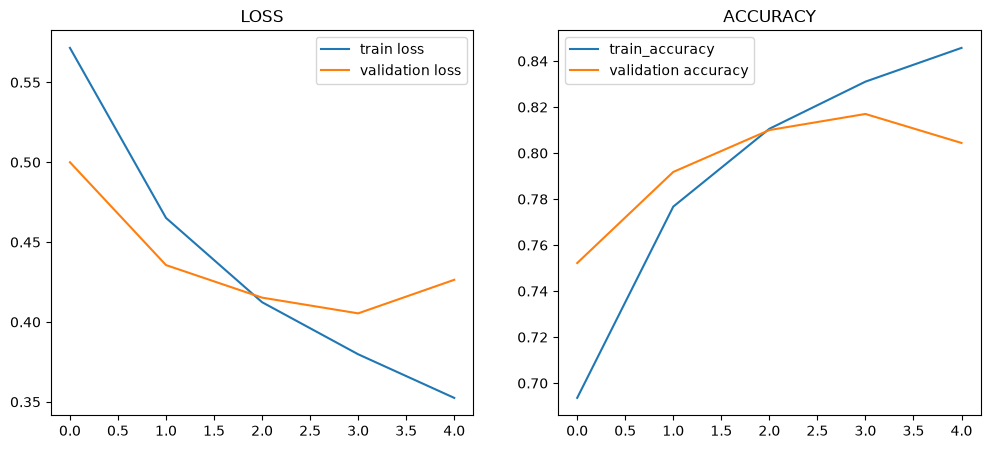

In [68]:
monitor.plot()

In [69]:
test_loss, test_acc = validate(model, test_loader, device, criterion)

In [70]:
print(f'Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}')

Test Loss: 0.4338 | Test Accuracy: 0.7972


In [112]:
test_batch = next(iter(test_loader))

In [115]:
model.eval()
with torch.no_grad():
    logits = model(
        input_ids=test_batch['input_ids'].to(device),
        attention_mask=test_batch['attention_mask'].to(device)
    )

In [116]:
prediction = logits.argmax(dim=1)
print(prediction)

tensor([0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 1, 0], device='cuda:0')


In [117]:
test_batch['label']

tensor([0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1,
        0, 0, 1, 1, 1, 1, 1, 1])

In [121]:
print(tokenizer.convert_ids_to_tokens(test_batch['input_ids'][0]))

['[CLS]', 'although', 'it', 'has', 'been', '2', 'years', ',', 'i', 'still', 'remember', 'the', 'complete', 'waste', 'that', 'comprises', 'the', 'entire', 'plot', 'of', 'the', 'movie', '.', 'unfortunately', ',', 'i', 'came', 'across', 'this', 'movie', 'after', 'my', 'friends', 'and', 'i', 'selected', 'it', 'while', 'brows', '##ing', 'through', 'the', 'new', 'releases', 'at', 'blockbuster', '.', 'we', 'decided', 'to', 'pick', 'the', 'movie', 'because', 'it', 'was', 'the', 'only', 'one', 'we', 'all', 'had', 'not', 'seen', 'and', 'it', 'sounded', 'like', 'it', 'may', 'be', 'enjoyable', '.', 'although', 'it', 'has', 'been', 'quite', 'some', 'time', 'since', 'i', 'viewed', 'the', 'movie', ',', 'i', 'still', 'remember', 'the', 'lack', 'of', 'plot', '(', 'seriously', ',', 'there', 'is', 'no', 'true', 'plot', ')', ',', 'and', 'complete', 'waste', 'of', 'time', 'that', 'was', 'spent', 'watching', 'the', 'movie', '.', 'if', 'you', 'are', 'in', 'the', 'video', 'store', 'and', 'this', 'film', 'catc

In [123]:
print(test_batch['label'][0].item())

0


In [124]:
print(tokenizer.convert_ids_to_tokens(test_batch['input_ids'][-1]))

['[CLS]', 'when', 'i', 'saw', 'this', 'movie', 'in', 'the', 'theater', 'when', 'it', 'came', 'out', 'in', '1995', 'via', 'a', 'free', 'advanced', 'screening', ',', 'i', 'was', 'totally', 'enchanted', 'and', 'would', 'have', 'gladly', 'paid', 'to', 'see', 'it', '.', 'i', 'was', 'sorry', 'when', 'i', 'talked', 'to', 'many', 'people', 'afterwards', 'who', 'had', 'also', 'seen', 'it', 'and', 'who', 'were', 'totally', 'disappointed', 'with', 'it', 'and', 'how', 'it', 'ended', '.', 'i', ',', 'on', 'the', 'other', 'hand', ',', 'felt', 'completely', 'the', 'opposite', '.', 'i', 'was', 'totally', 'satisfied', 'with', 'the', 'outcome', 'and', 'everything', 'else', '.', 'people', 'i', 'talked', 'to', 'said', 'there', 'was', 'too', 'much', 'talking', '!', 'plus', 'they', 'were', 'unhappy', 'because', 'they', 'felt', 'that', 'the', 'ending', 'left', 'you', 'wondering', 'about', 'the', 'fate', 'of', 'the', 'two', 'characters', '.', 'i', 'found', 'these', 'observations', 'to', 'be', 'absurd', 'and', 

In [125]:
print(test_batch['label'][-1].item())

1
